# Noise ceiling of the crossnobis RDM

How much of the representational geometry is reproducible across participants, and therefore how well any model *could* do, computed by `pattern.make_noise_ceiling_dataframe` (leave-one-participant-out, `pattern._noise_ceiling`).

For every hemisphere x roi x session, each participant's vectorised crossnobis RDM is correlated with the group mean RDM:

- **lower**: against the mean of the *other* participants. The reference is estimated without them, so this is what a model that generalises across participants can be expected to reach.
- **upper**: against the mean of *all* participants, that participant included. The reference is fitted to the participant it is scored on, so it overestimates and no model should beat it.

The table holds one row per participant, so the ceiling of a cell is the mean of its rows.

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import EFC_learningfMRI.vis as vis
import EFC_learningfMRI.util as util

# Noise ceilings
## Load data

In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants
nc = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'noise_ceiling.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
nc_long = nc.melt(id_vars=['sn', 'Hem', 'roi', 'session'], value_vars=['lower', 'upper'], var_name='bound', value_name='r')

# Upper and lower noise ceiling
The noise ceilings were defined as the mean correlation of each participant's crossnobis dissimilarities with the group mean (upper noise ceiling) or with the group mean of the other participants (lower noice ceiling). The noise ceilings were significantly >0 in all ROIs, suggesting consistent representational geometry across participants. The increasing gap between upper and lower noise ceiling across sessions reflect the fact that each participant practiced a different set of trained chords.

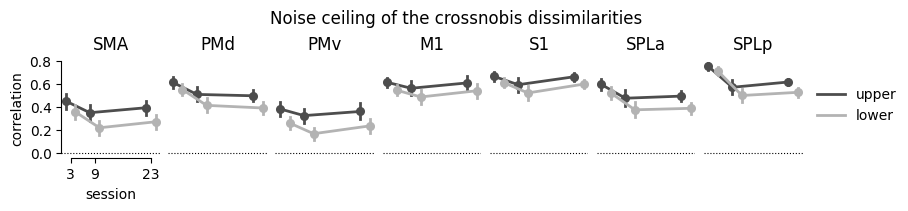

In [4]:
hue_order = ['upper', 'lower']
palette   = ['0.3', '0.7']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(9, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, nc_long[nc_long.Hem == H], rois, y='r', x='session', hue='bound',
             hue_order=hue_order, palette=palette, kind='point', dodge=.4, add_zero=True, legend=False)
custom_legend(fig, hue_order, palette, loc='outside right center')
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('correlation')
axs[0].set_xlabel('session')

fig.suptitle(f'Noise ceiling of the crossnobis dissimilarities')

fig.savefig(os.path.join(gl.figDir, 'noise_ceiling_bounds.pdf'))

blocks = []
for bound in hue_order:
    t = util.ttest_im_sess(nc[nc.Hem == H], rois, y=bound, x='session')
    blocks.append(t.assign(bound=bound))          # tag the rows, so the blocks stay apart once stacked

ttest = pd.concat(blocks, ignore_index=True)
ttest = ttest.sort_values(by=['bound', 'session'], kind='stable')

print(ttest[['bound', 'roi', 'session', 'T', 'dof', 'p_val', 'CI95', 'cohen_d']].to_string(index=False))

plt.show()